# Explorative analysis of customer data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)


### Data loading

Load each dataset and understand what it contains

customer_data.csv

In [4]:
customers_df = pd.read_csv("../customer_data.csv")
display(customers_df.describe().round(2))
# display(customers_df.head())
# quantiles = customers_df["total_amount"].quantile(
#     [0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
# )
# display(quantiles)


,customer_id,n_country,n_transactions,total_amount,n_counterparts,days_active,pos_perc,ecom_perc,cat_cash,cat_communication,cat_education,cat_entertainment,cat_fitness,cat_general,cat_groceries,cat_health,cat_holidays,cat_hotel,cat_lebensmittel,cat_living,cat_restaurant,cat_restaurants,cat_salary,cat_savings,cat_shopping,cat_tax,cat_transport,cat_wellness,cur_aud,cur_chf,cur_eur,cur_gbp,cur_mxn,cur_thb,cur_usd,country_ch,country_de,country_fr,country_gb,country_ie,country_it,country_us
count,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00,5576.00
mean,2787.50,5.20,237.22,10799.02,76.57,398.96,0.60,0.40,1285.99,443.48,5.63,787.96,0.02,279.23,1872.93,280.86,1171.80,0.23,0.20,81.96,0.82,1440.53,0.73,249.78,1996.13,56.09,835.79,8.96,28.55,7863.18,1983.22,80.65,28.23,21.52,407.26,166.85,9.56,4.33,6.84,7.08,4.84,7.41
std,1609.80,4.92,440.77,22902.37,124.45,339.24,0.37,0.37,5405.95,1561.06,217.78,5526.95,1.13,1900.78,4877.57,901.26,4048.26,15.84,14.69,574.10,20.90,3894.57,23.11,2056.39,5835.03,302.91,2116.31,200.69,494.44,17737.01,5956.07,561.63,624.75,358.00,2061.21,347.99,36.01,21.86,26.76,26.34,21.93,31.61
min,0.00,1.00,1.00,0.05,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1393.75,1.00,7.00,150.23,4.00,64.00,0.27,0.03,0.00,0.00,0.00,0.00,0.00,0.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,106.32,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2787.50,3.00,49.00,1864.72,22.00,339.00,0.71,0.29,0.00,7.00,0.00,19.00,0.00,0.00,144.00,0.00,0.00,0.00,0.00,0.00,0.00,92.50,0.00,0.00,166.00,0.00,54.00,0.00,0.00,1052.92,49.24,0.00,0.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,4181.25,8.00,260.00,10734.86,92.00,696.00,0.97,0.73,353.25,225.00,0.00,296.00,0.00,75.00,1154.25,147.25,418.25,0.00,0.00,0.00,0.00,1036.00,0.00,0.00,1471.00,10.00,597.00,0.00,0.00,6782.69,1175.11,0.00,0.00,0.00,35.49,144.00,5.00,1.00,3.00,1.00,0.00,1.00
max,5575.00,33.00,5732.00,333261.57,1194.00,964.00,1.00,1.00,108786.00,40010.00,15254.00,247950.00,73.00,94262.00,86636.00,25003.00,100259.00,1176.00,1097.00,31114.00,1387.00,80175.00,1312.00,60810.00,190008.00,9658.00,28554.00,8743.00,20002.91,210670.03,99352.23,22209.08,29237.17,21420.09,50946.76,4362.00,1300.00,575.00,791.00,821.00,581.00,616.00


customer_data_labels.csv

In [5]:
customers_labeled_df = pd.read_csv("../customer_data_labels.csv")
display(customers_labeled_df.head())
labeled_counts = customers_labeled_df["churned"].value_counts(dropna=False)
display(labeled_counts)
print("NA:", labeled_counts.get(np.nan, 0))

,customer_id,churned
0,4683,True
1,4514,False
2,619,True
3,1995,True
4,2361,False


churned
True     2140
False    1763
Name: count, dtype: int64

NA: 0


### Data cleanup

To do: 
- add steps to check that data_predict and data_labels match the customer_data (Zeynep already did this)
- clean up the dataset: merge duplicate columns

### Customer analysis - churned vs active

Use the churned/retained labels to form the 2 groups of customers

In [16]:
customers_merged_df = customers_df.merge(customers_labeled_df, on="customer_id", how="inner")
customers_merged_df["segment"] = customers_merged_df["churned"].map({
    True: "Churned",
    False: "Active"
})
numeric_cols = customers_merged_df.select_dtypes(include="number").columns.drop(
    "customer_id",
    errors="ignore"
)
display(customers_merged_df.groupby("segment")[numeric_cols].describe().round(2))

n_country                                        n_transactions  \
            count  mean   std  min  25%  50%   75%   max          count   
segment                                                                   
Active     1763.0  7.69  5.35  1.0  3.0  7.0  11.0  33.0         1763.0   
Churned    2140.0  3.08  3.28  1.0  1.0  2.0   4.0  24.0         2140.0   

                                                         total_amount  \
           mean     std  min   25%    50%    75%     max        count   
segment                                                                 
Active   418.05  544.03  1.0  59.0  205.0  555.0  4180.0       1763.0   
Churned   78.29  198.24  1.0   3.0   10.0   54.0  2524.0       2140.0   

                                                                          \
             mean       std   min      25%      50%       75%        max   
segment                                                                    
Active   19068.39  29892.90  2.00  2225.05  8093.73  23065.29  317171.31   
Churned   3697.40  10379.22  0.05    61.86   260.00   2236.51  165156.98   

        n_counterparts                                                  \
                 count    mean     std  min   25%   50%    75%     max   
segment                                                                  
Active          1763.0  134.01  153.91  1.0  25.0  75.0  188.0  1194.0   
Churned         2140.0   27.82   57.04  1.0   2.0   6.0   25.0   533.0   

        days_active                                                  pos_perc  \
              count    mean     std  min    25%    50%    75%    max    count   
segment                                                                         
Active       1763.0  594.10  314.63  1.0  330.5  626.0  915.5  964.0   1763.0   
Churned      2140.0  229.22  257.15  1.0   12.0  125.0  377.0  963.0   2140.0   

                                                ecom_perc                   \
         mean   std  min   25%   50%   75%  max     count  mean   std  min   
segment                                                                      
Active   0.64  0.31  0.0  0.44  0.71  0.91  1.0    1763.0  0.36  0.31  0.0   
Churned  0.58  0.41  0.0  0.07  0.72  1.00  1.0    2140.0  0.42  0.41  0.0   

                               cat_cash                                    \
          25%   50%   75%  max    count     mean      std  min  25%   50%   
segment                                                                     
Active   0.09  0.29  0.56  1.0   1763.0  1846.83  6790.48  0.0  0.0  25.0   
Churned  0.00  0.28  0.93  1.0   2140.0   741.78  3661.57  0.0  0.0   0.0   

                          cat_communication                                   \
            75%       max             count    mean      std  min  25%   50%   
segment                                                                        
Active   1000.0  108786.0            1763.0  724.67  1932.68  0.0  0.0  97.0   
Churned    56.5   76958.0            2140.0  204.91  1327.14  0.0  0.0   0.0   

                        cat_education                                     \
           75%      max         count   mean     std  min  25%  50%  75%   
segment                                                                    
Active   611.0  39783.0        1763.0  14.81  377.08  0.0  0.0  0.0  0.0   
Churned   28.0  40010.0        2140.0   2.29   79.76  0.0  0.0  0.0  0.0   

                 cat_entertainment                                             \
             max             count     mean      std  min   25%    50%    75%   
segment                                                                         
Active   15254.0            1763.0  1321.05  7964.68  0.0  10.0  177.0  792.5   
Churned   3628.0            2140.0   366.87  2683.15  0.0   0.0    0.0   44.0   

                  cat_fitness                                        \
              max       count  mean   std  min  25%  50%  75%   max   
s

Plot the distribution for the total amount, number of transactions, active days and ecommerce vs in point of sale usage.

How to read it:
A box plot shows the distribution of a variable for each customer segment:

Line inside the box: median (50th percentile)
Bottom/top of box: 25th and 75th percentiles
Box height: middle 50% of observations
Whiskers: typical minimum and maximum values
Dots: outliers

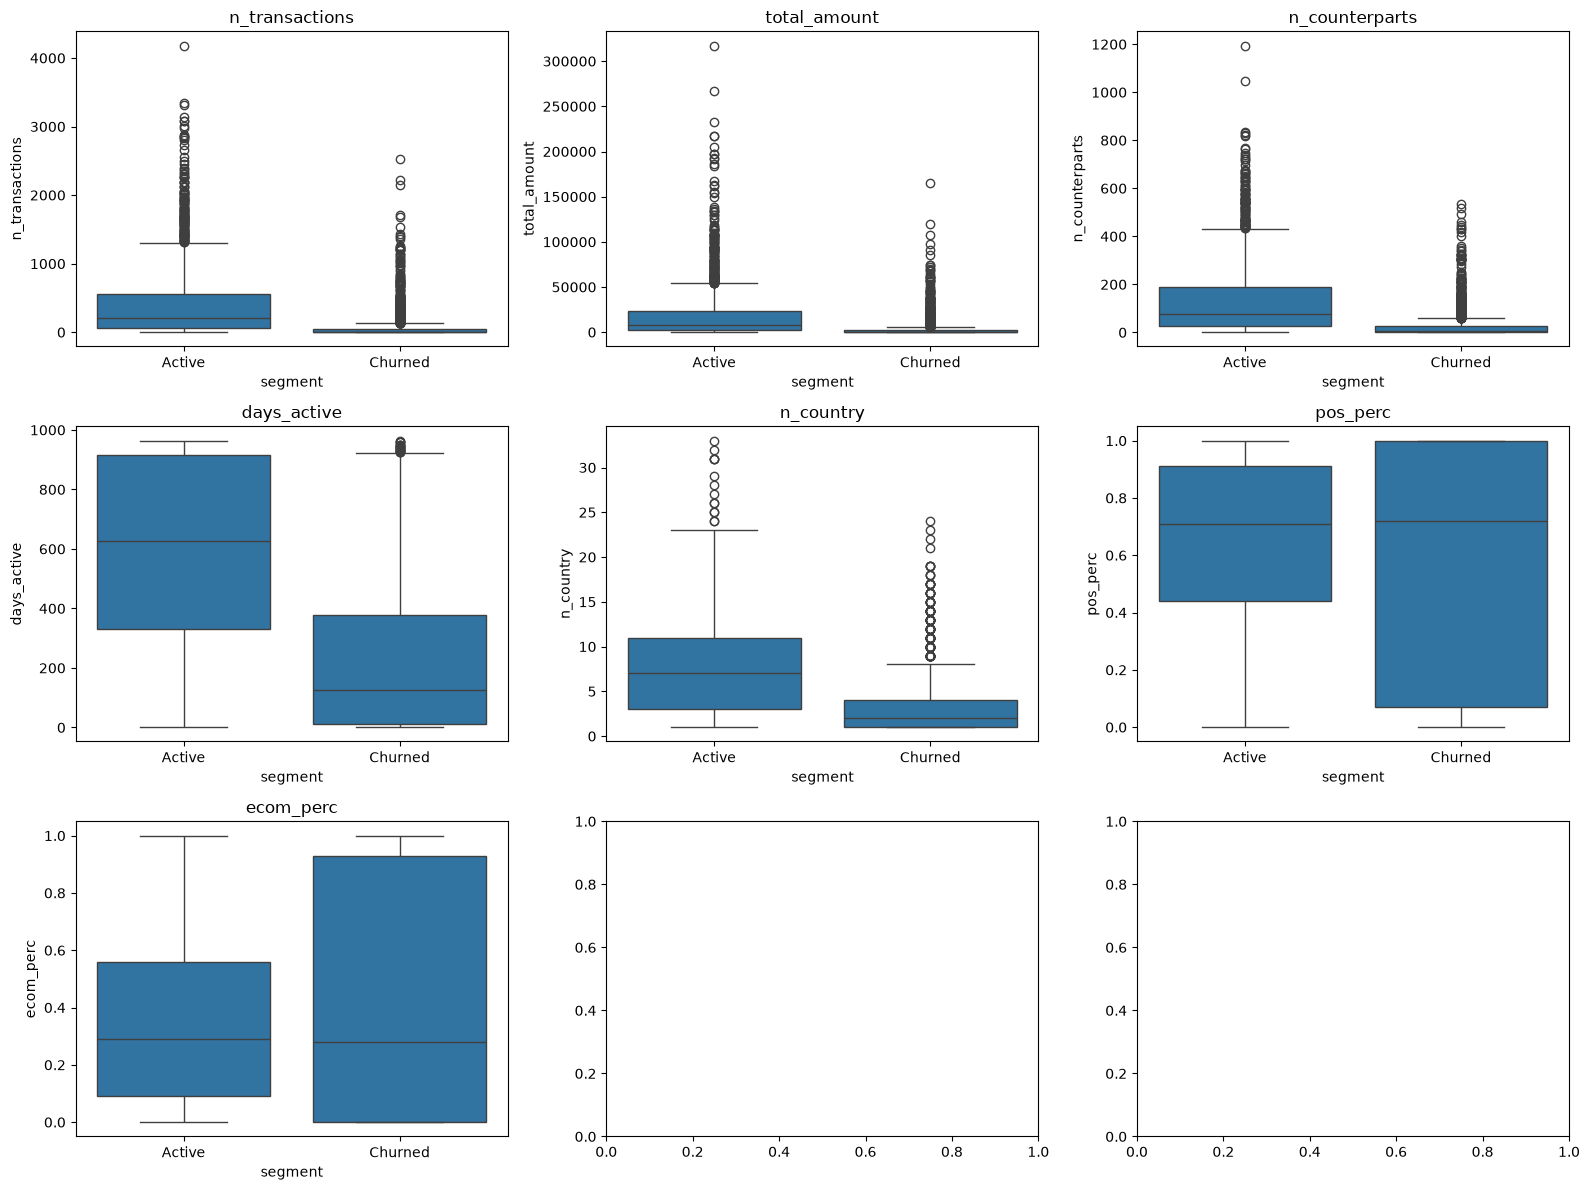

In [17]:
comparison_cols = [
    "n_transactions",
    "total_amount",
    "n_counterparts",
    "days_active",
    "n_country",
    "pos_perc",
    "ecom_perc"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flat

for axis, column in zip(axes, comparison_cols):
    sns.boxplot(
        data=customers_merged_df,
        x="segment",
        y=column,
        ax=axis
    )
    axis.set_title(column)

plt.tight_layout()
plt.show()

Interpretation:

- `total_amount`: Active customers generally spend considerably more. Both groups have many high-value outliers.
- `n_transactions`: Active customers make more transactions. Churned customers are concentrated at much lower values.
- `days_active`: Active customers are active for much longer. This appears to be the clearest difference.
- `pos_perc`: The medians are similar, but churned customers show greater variability.
- `ecom_perc`: The medians are also similar, although churned customers have a wider distribution.

In [18]:
category_cols = [
    column for column in customers_merged_df.columns
    if column.startswith("cat_")
]

category_summary = (
    customers_merged_df
    .groupby("segment")[category_cols]
    .agg(["min", "median", "max"])
    .round(0)
)
display(category_summary)

cat_cash                  cat_communication                  \
             min median       max               min median      max   
segment                                                               
Active       0.0   25.0  108786.0               0.0   97.0  39783.0   
Churned      0.0    0.0   76958.0               0.0    0.0  40010.0   

        cat_education                 cat_entertainment                   \
                  min median      max               min median       max   
segment                                                                    
Active            0.0    0.0  15254.0               0.0  177.0  247950.0   
Churned           0.0    0.0   3628.0               0.0    0.0   63979.0   

        cat_fitness              cat_general                 cat_groceries  \
                min median   max         min median      max           min   
segment                                                                      
Active          0.0    0.0  73.0         0.0   28.0  53174.0           0.0   
Churned         0.0    0.0  10.0         0.0    0.0  94262.0           0.0   

                        cat_health                 cat_holidays         \
        median      max        min median      max          min median   
segment                                                                  
Active   811.0  86636.0        0.0   88.0  15860.0          0.0  234.0   
Churned   30.0  31342.0        0.0    0.0   6161.0          0.0    0.0   

                  cat_hotel             cat_lebensmittel                 \
              max       min median  max              min median     max   
segment                                                                   
Active   100259.0       0.0    0.0  0.0              0.0    0.0  1097.0   
Churned   13671.0       0.0    0.0  0.0              0.0    0.0     0.0   

        cat_living                 cat_restaurant                 \
               min median      max            min median     max   
segment                                                            
Active         0.0    0.0   9350.0            0.0    0.0  1387.0   
Churned        0.0    0.0  31114.0            0.0    0.0   126.0   

        cat_restaurants                 cat_salary                cat_savings  \
                    min median      max        min median     max         min   
segment                                                                         
Active              0.0  716.0  71365.0        0.0    0.0   101.0         0.0   
Churned             0.0   10.0  17076.0        0.0    0.0  1312.0         0.0   

                        cat_shopping                   cat_tax                 \
        median      max          min  median       max     min median     max   
segment                                                                         
Active     0.0  35721.0          0.0  1066.0  101363.0     0.0    0.0  9649.0   
Churned    0.0  37067.0          0.0    11.0   36383.0     0.0    0.0  3147.0   

        cat_transport                 cat_wellness                 
                  min median      max          min median     max  
segment                                                            
Active            0.0  440.0  26974.0          0.0    0.0  8743.0  
Churned           0.0    2.0  19669.0          0.0    0.0   450.0

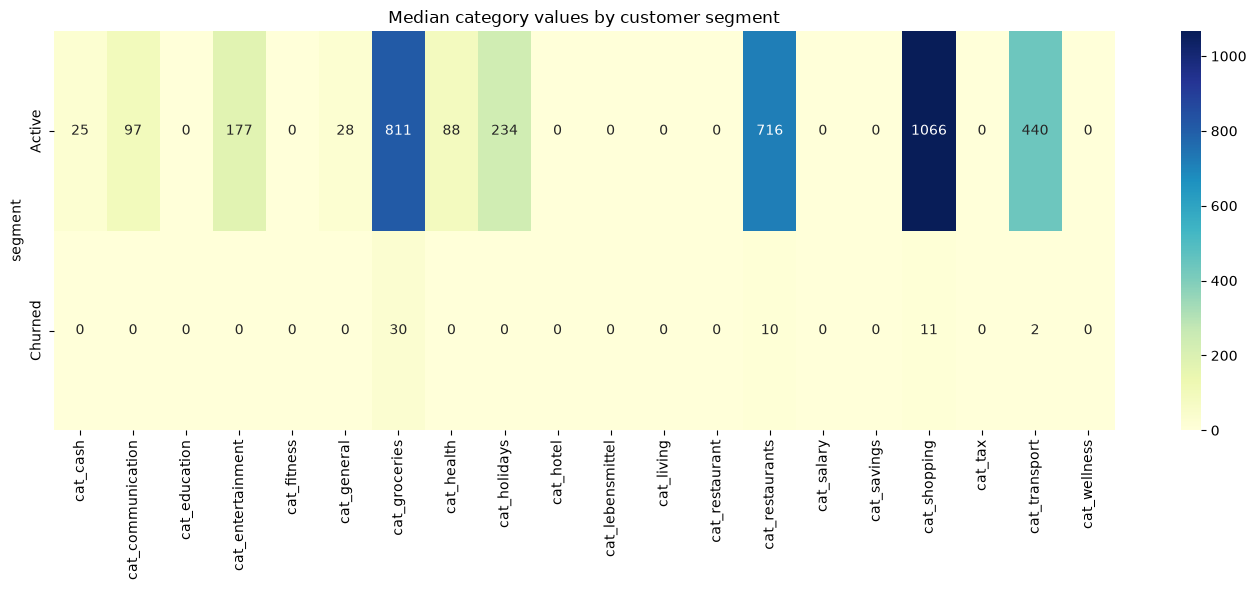

In [19]:
category_medians = (
    customers_merged_df
    .groupby("segment")[category_cols]
    .median()
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    category_medians,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Median category values by customer segment")
plt.tight_layout()
plt.show()

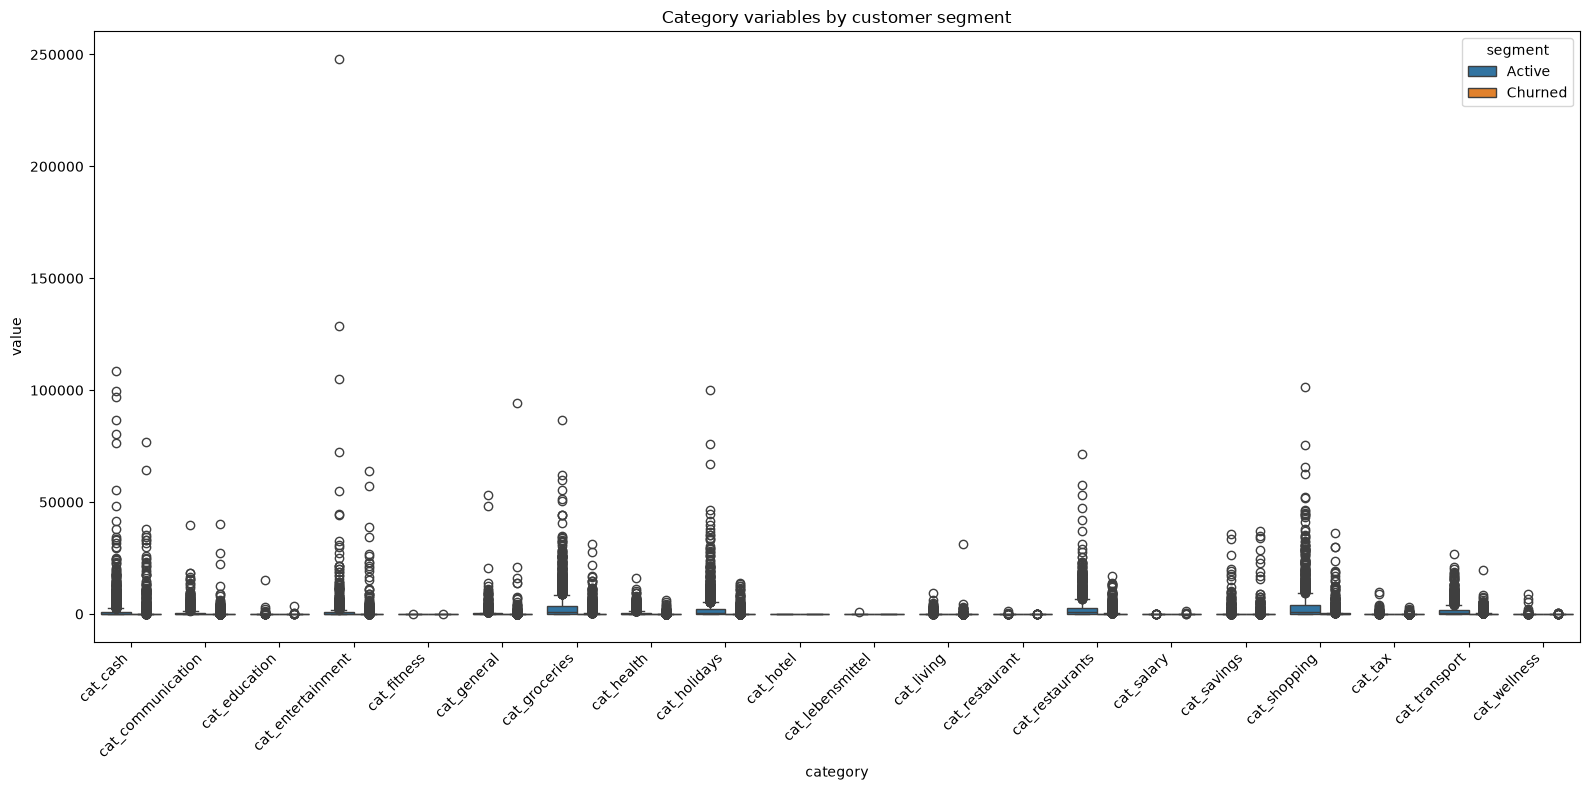

In [20]:
category_long = customers_merged_df.melt(
    id_vars="segment",
    value_vars=category_cols,
    var_name="category",
    value_name="value"
)

plt.figure(figsize=(16, 8))

sns.boxplot(
    data=category_long,
    x="category",
    y="value",
    hue="segment"
)

plt.xticks(rotation=45, ha="right")
plt.title("Category variables by customer segment")
plt.tight_layout()
plt.show()

There are many outliers, so I'm converting the y axis to a logarithmic scale. log1p(x) = log(x+1) -> we use this to avoid infinite values when x is zero.

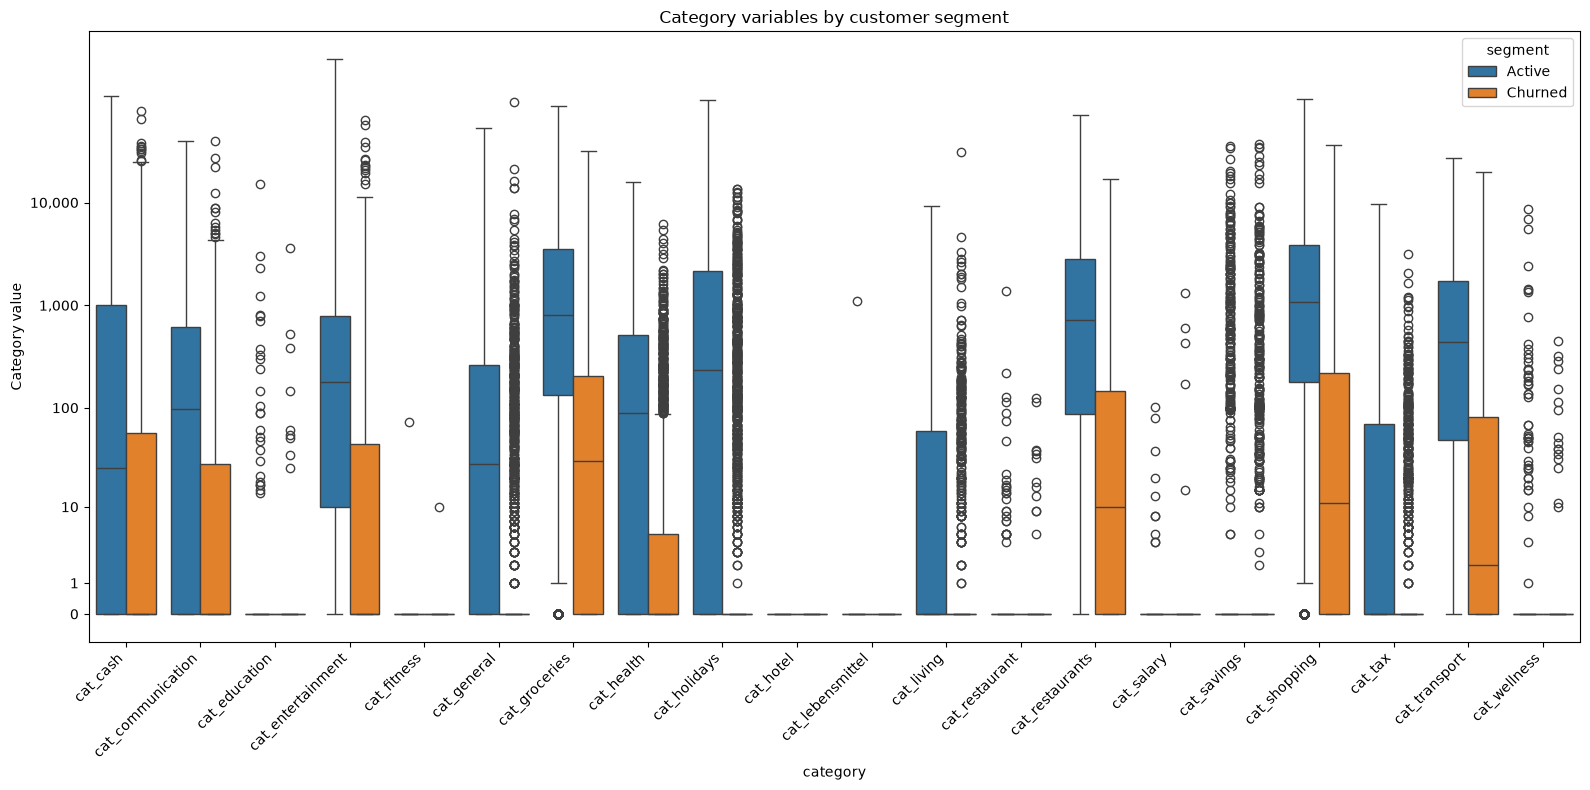

In [22]:
category_long["log_value"] = np.log1p(category_long["value"])

fig, ax = plt.subplots(figsize=(16, 8))

sns.boxplot(
    data=category_long,
    x="category",
    y="log_value",
    hue="segment",
    ax=ax
)
# Choose original-value positions for the tick labels
real_values = np.array([0, 1, 10, 100, 1_000, 10_000])
log_positions = np.log1p(real_values)

ax.set_yticks(log_positions)
ax.set_yticklabels([f"{value:,}" for value in real_values])
ax.set_ylabel("Category value")
ax.set_title("Category variables by customer segment")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()